# Projet 5 — Prévision de la Consommation Électrique
**Étudiant :** Mohamed Mahmoud El Atigh  
**Matricule :** C34621  
**Dataset :** Individual Household Electric Power Consumption (UCI)  
**Professeur :** Ezyn SEGNANE

---

## Pipeline complet :
1. Chargement & Exploration (EDA)
2. Nettoyage & Imputation
3. Transformation & Resampling
4. Séparation Train / Validation / Test
5. Modélisation (Régression Linéaire, Random Forest, XGBoost, ARIMA, LSTM)
6. Évaluation & Comparaison (RMSE, MAE, R²)
7. Interprétation & Importance des variables

## 📦 Installation des dépendances
Exécuter cette cellule une seule fois si les librairies ne sont pas installées.

In [1]:
# ============================================================
# INSTALLATION DES LIBRAIRIES (à exécuter une seule fois)
# ============================================================
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'xgboost', 'statsmodels',
    'tensorflow', 'plotly'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Toutes les librairies sont installées !')

✅ Toutes les librairies sont installées !


---
## 1️⃣ Chargement des données & Exploration (EDA)

In [3]:
# ============================================================
# IMPORTS GÉNÉRAUX
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style graphique
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

print('✅ Imports OK')

✅ Imports OK


In [5]:
# ============================================================
# CHARGEMENT DU DATASET
# ============================================================
# 📁 Assurez-vous que le fichier 'household_power_consumption.txt'
#    est dans le même dossier que ce notebook.

df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    na_values='?',        # Remplacer '?' par NaN
    low_memory=False
)

print(f'🔢 Lignes : {len(df):,} | Colonnes : {df.shape[1]}')
print(f'📅 Période : {df["Date"].iloc[0]} → {df["Date"].iloc[-1]}')
df.head(3)

🔢 Lignes : 2,075,259 | Colonnes : 9
📅 Période : 16/12/2006 → 26/11/2010


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


In [7]:
# ============================================================
# FUSION Date + Time → Index datetime
# ============================================================
df['Date_time'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)
df = df.drop(columns=['Date', 'Time'])
df = df.set_index('Date_time')
df = df.sort_index()

print('✅ Index Date_time créé :', df.index.dtype)
df.head(3)

✅ Index Date_time créé : datetime64[ns]


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Date_time,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


In [9]:
# ============================================================
# TYPES ET VALEURS MANQUANTES
# ============================================================
# Conversion en numérique (déjà géré par na_values='?')
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print('\n📊 Valeurs manquantes par colonne :')
print(pd.DataFrame({'Manquants': missing, '% Manquants': missing_pct}))
print(f'\n💡 Total NaN : {df.isnull().sum().sum():,} / {df.size:,} valeurs')


📊 Valeurs manquantes par colonne :
                       Manquants  % Manquants
Global_active_power        25979         1.25
Global_reactive_power      25979         1.25
Voltage                    25979         1.25
Global_intensity           25979         1.25
Sub_metering_1             25979         1.25
Sub_metering_2             25979         1.25
Sub_metering_3             25979         1.25

💡 Total NaN : 181,853 / 14,526,813 valeurs


In [11]:
# ============================================================
# EDA — STATISTIQUES DESCRIPTIVES
# ============================================================
print('📊 Statistiques descriptives :')
df.describe().T

📊 Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


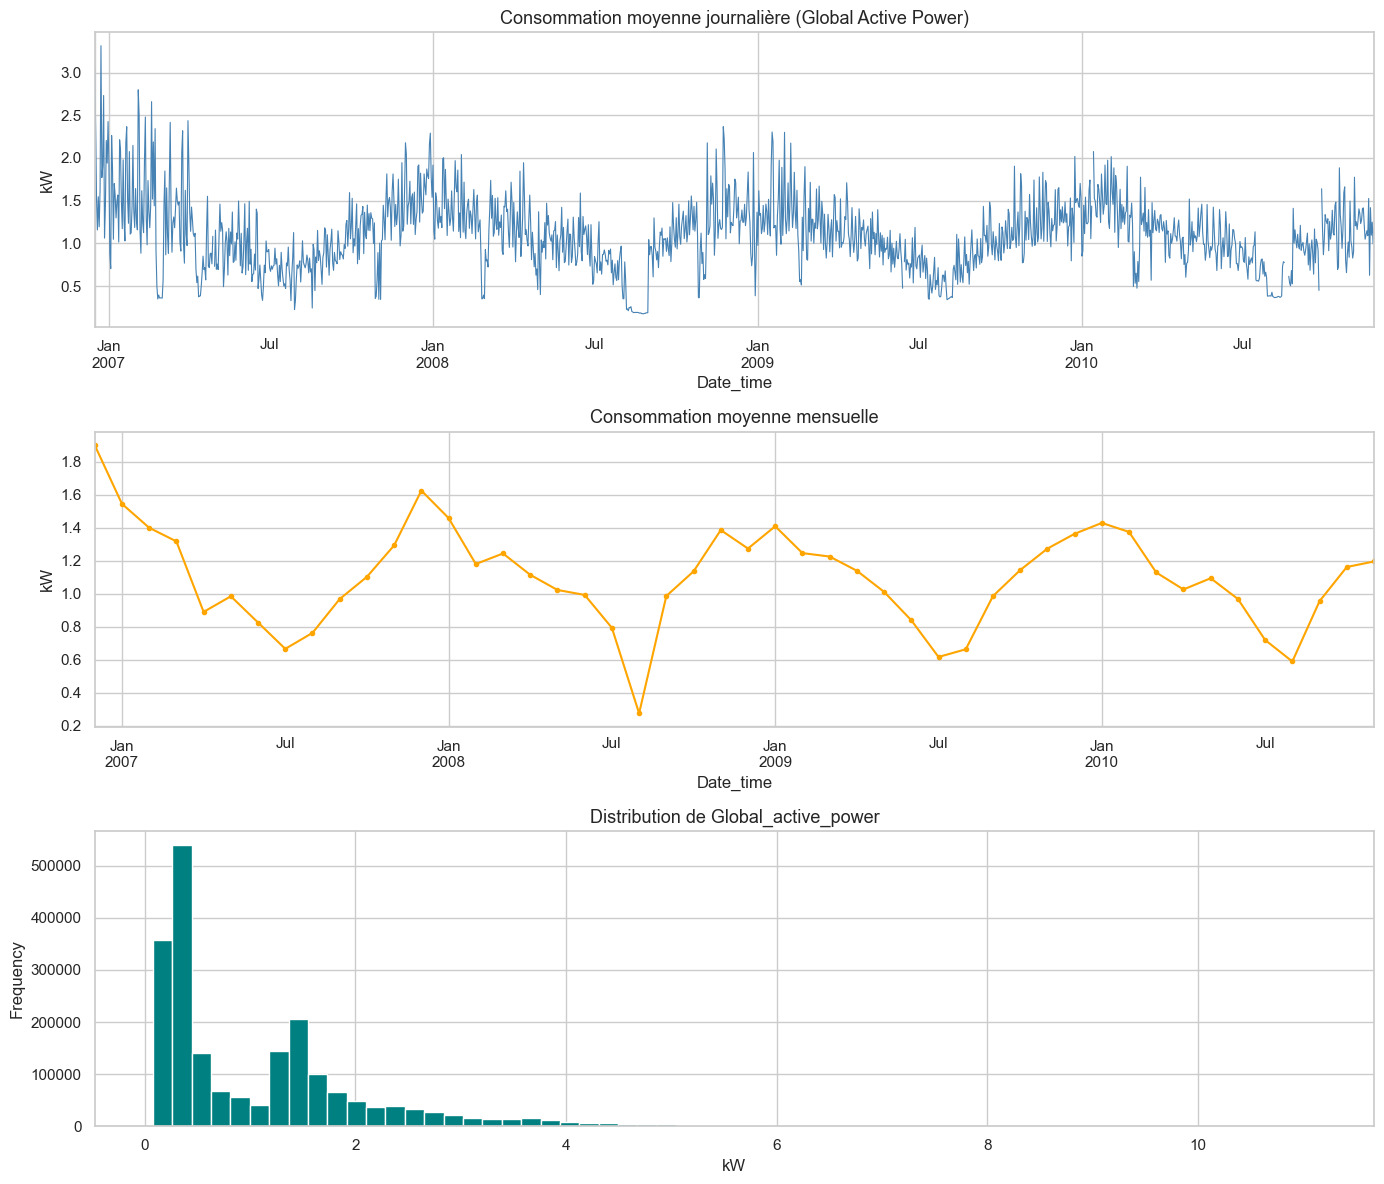

✅ Graphique sauvegardé : eda_serie_temporelle.png


In [13]:
# ============================================================
# EDA — VISUALISATION DE LA SÉRIE TEMPORELLE (Global_active_power)
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Données brutes (échantillon)
df['Global_active_power'].resample('D').mean().plot(
    ax=axes[0], color='steelblue', linewidth=0.8
)
axes[0].set_title('Consommation moyenne journalière (Global Active Power)', fontsize=13)
axes[0].set_ylabel('kW')

# Moyenne mensuelle
df['Global_active_power'].resample('ME').mean().plot(
    ax=axes[1], color='orange', marker='o', markersize=3
)
axes[1].set_title('Consommation moyenne mensuelle', fontsize=13)
axes[1].set_ylabel('kW')

# Distribution
df['Global_active_power'].dropna().plot(
    kind='hist', bins=60, ax=axes[2], color='teal', edgecolor='white'
)
axes[2].set_title('Distribution de Global_active_power', fontsize=13)
axes[2].set_xlabel('kW')

plt.tight_layout()
plt.savefig('eda_serie_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : eda_serie_temporelle.png')

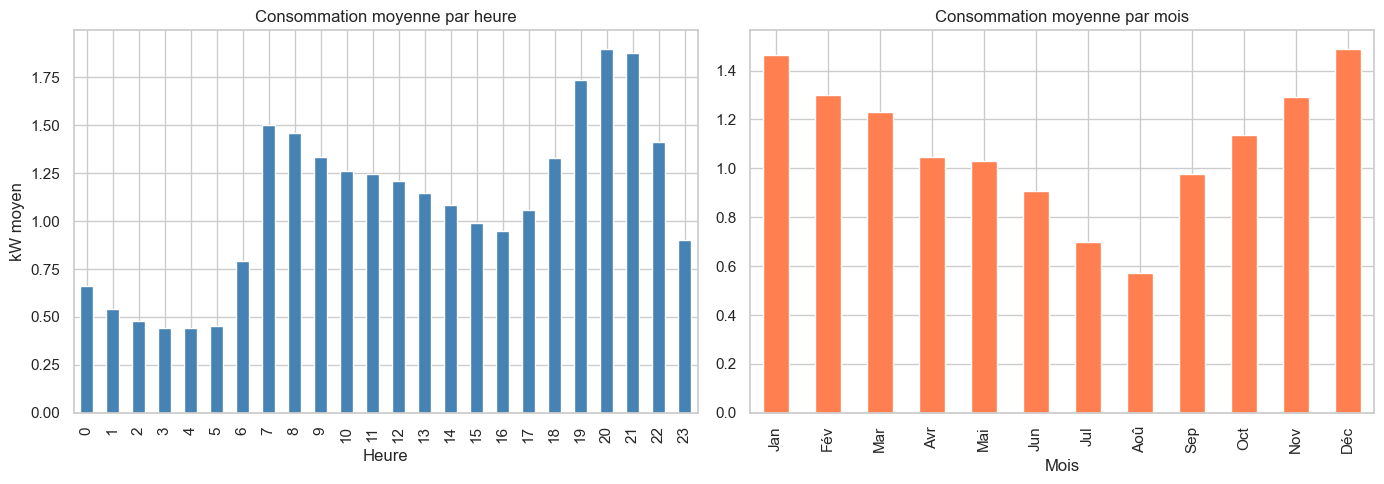

In [15]:
# ============================================================
# EDA — SAISONNALITÉ PAR HEURE & PAR MOIS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par heure de la journée
hourly = df.groupby(df.index.hour)['Global_active_power'].mean()
hourly.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Consommation moyenne par heure')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('kW moyen')

# Par mois
monthly = df.groupby(df.index.month)['Global_active_power'].mean()
monthly.index = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
monthly.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Consommation moyenne par mois')
axes[1].set_xlabel('Mois')

plt.tight_layout()
plt.savefig('eda_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

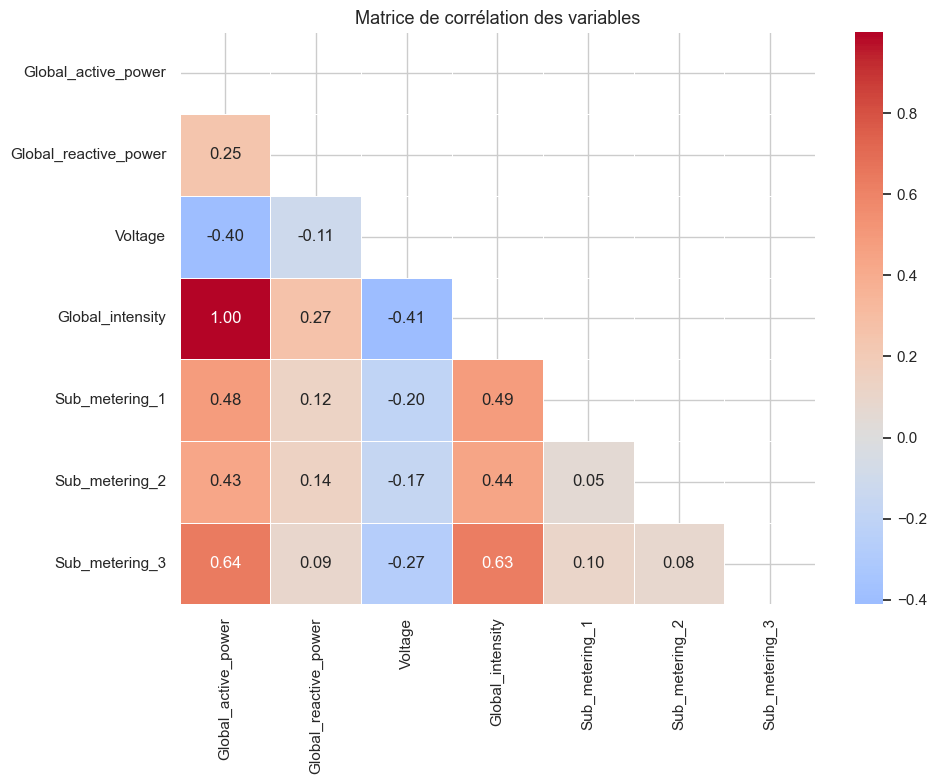

💡 Global_active_power est fortement corrélé à Global_intensity et Sub_metering_3


In [17]:
# ============================================================
# EDA — MATRICE DE CORRÉLATION
# ============================================================
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5
)
plt.title('Matrice de corrélation des variables', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Global_active_power est fortement corrélé à Global_intensity et Sub_metering_3')

---
## 2️⃣ Nettoyage & Imputation des valeurs manquantes

In [19]:
# ============================================================
# IMPUTATION PAR INTERPOLATION TEMPORELLE
# ============================================================
# La méthode 'time' respecte l'axe temporel — meilleure que fillna(mean)
# car elle tient compte de la position chronologique des NaN

df_clean = df.interpolate(method='time').ffill().bfill()

# Vérification
remaining_nan = df_clean.isnull().sum().sum()
print(f'✅ NaN restants après imputation : {remaining_nan}')
print(f'📊 Lignes conservées : {len(df_clean):,}')

✅ NaN restants après imputation : 0
📊 Lignes conservées : 2,075,259


---
## 3️⃣ Transformation & Resampling

In [21]:
# ============================================================
# RESAMPLING JOURNALIER (pour réduire le bruit)
# ============================================================
# On agrège à la journée : moyenne pour les puissances, tension, intensité
# Somme pour les sous-compteurs (énergie totale/jour)

df_daily = pd.DataFrame()
df_daily['Global_active_power']    = df_clean['Global_active_power'].resample('D').mean()
df_daily['Global_reactive_power']  = df_clean['Global_reactive_power'].resample('D').mean()
df_daily['Voltage']                = df_clean['Voltage'].resample('D').mean()
df_daily['Global_intensity']       = df_clean['Global_intensity'].resample('D').mean()
df_daily['Sub_metering_1']         = df_clean['Sub_metering_1'].resample('D').sum()
df_daily['Sub_metering_2']         = df_clean['Sub_metering_2'].resample('D').sum()
df_daily['Sub_metering_3']         = df_clean['Sub_metering_3'].resample('D').sum()

print(f'✅ Dataset journalier : {df_daily.shape}')
df_daily.head(3)

✅ Dataset journalier : (1442, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Date_time,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.0,546.0,4926.0
2006-12-17,2.354486,0.156949,240.087028,9.999028,2033.0,4187.0,13341.0
2006-12-18,1.530435,0.112356,241.231694,6.421667,1063.0,2621.0,14018.0


In [23]:
# ============================================================
# FEATURE ENGINEERING — Variables temporelles
# ============================================================
# Ces features permettent aux modèles ML de capturer la saisonnalité

df_daily['day_of_week']  = df_daily.index.dayofweek    # 0=Lundi, 6=Dimanche
df_daily['month']        = df_daily.index.month
df_daily['quarter']      = df_daily.index.quarter
df_daily['year']         = df_daily.index.year
df_daily['is_weekend']   = (df_daily.index.dayofweek >= 5).astype(int)

# Lags (valeurs passées comme features) — capturent l'autocorrélation
df_daily['lag_1']   = df_daily['Global_active_power'].shift(1)   # Hier
df_daily['lag_7']   = df_daily['Global_active_power'].shift(7)   # Semaine précédente
df_daily['lag_30']  = df_daily['Global_active_power'].shift(30)  # Mois précédent

# Moyenne mobile (tendance lissée)
df_daily['rolling_7']   = df_daily['Global_active_power'].shift(1).rolling(7).mean()
df_daily['rolling_30']  = df_daily['Global_active_power'].shift(1).rolling(30).mean()

df_daily = df_daily.dropna()  # Supprimer les NaN créés par les lags

print(f'✅ Dataset enrichi : {df_daily.shape}')
print(f'📅 Période finale : {df_daily.index[0].date()} → {df_daily.index[-1].date()}')
df_daily.head(3)

✅ Dataset enrichi : (1412, 17)
📅 Période finale : 2007-01-15 → 2010-11-26


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,month,quarter,year,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30
Date_time,,,,,,,,,,,,,,,,,
2007-01-15,1.492137,0.121431,241.240910,6.261528,1099.0,2239.0,15163.0,0,1,1,2007,0,2.090992,1.556500,3.053475,1.605114,1.762853
2007-01-16,1.171114,0.128769,241.944757,4.975972,2063.0,644.0,6583.0,1,1,1,2007,0,1.492137,1.297954,2.354486,1.595919,1.710808
2007-01-17,1.977561,0.139411,241.005250,8.283889,3500.0,5737.0,16064.0,2,1,1,2007,0,1.171114,1.496389,1.530435,1.577799,1.671363


In [27]:
# ============================================================
# NORMALISATION (MinMaxScaler)
# ============================================================
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'lag_1', 'lag_7', 'lag_30', 'rolling_7', 'rolling_30'
]

scaler = MinMaxScaler()
df_scaled = df_daily.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_daily[cols_to_scale])

# Scaler séparé pour la cible (pour pouvoir inverser plus tard)
target_scaler = MinMaxScaler()
target_scaler.fit(df_daily[['Global_active_power']])

print('✅ Normalisation effectuée')
print('Min GAP normalisé :', round(float(df_scaled['Global_active_power'].min()), 4))
print('Max GAP normalisé :', round(float(df_scaled['Global_active_power'].max()), 4))

✅ Normalisation effectuée
Min GAP normalisé : 0.0
Max GAP normalisé : 1.0


---
## 4️⃣ Séparation chronologique Train / Validation / Test

In [29]:
# ============================================================
# PARTITIONNEMENT TEMPOREL CHRONOLOGIQUE
# ============================================================
# ⚠️ On NE MÉLANGE PAS les données (pas de shuffle) pour respecter
# la dépendance temporelle. Le futur ne peut pas être dans le train !
#
# Ratio : 70% Train | 15% Validation | 15% Test

n = len(df_daily)
train_end  = int(n * 0.70)
val_end    = int(n * 0.85)

# Features & target
features = [
    'Global_reactive_power', 'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'day_of_week', 'month', 'quarter', 'year', 'is_weekend',
    'lag_1', 'lag_7', 'lag_30', 'rolling_7', 'rolling_30'
]
target = 'Global_active_power'

X = df_daily[features]
y = df_daily[target]

X_train, y_train = X.iloc[:train_end],  y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],    y.iloc[val_end:]

print(f'🔵 Train      : {len(X_train):4d} jours  ({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'🟡 Validation : {len(X_val):4d} jours  ({X_val.index[0].date()} → {X_val.index[-1].date()})')
print(f'🔴 Test       : {len(X_test):4d} jours  ({X_test.index[0].date()} → {X_test.index[-1].date()})')

🔵 Train      :  988 jours  (2007-01-15 → 2009-09-28)
🟡 Validation :  212 jours  (2009-09-29 → 2010-04-28)
🔴 Test       :  212 jours  (2010-04-29 → 2010-11-26)


---
## 5️⃣ Modélisation — Régression Linéaire

In [31]:
# ============================================================
# MÉTRIQUES D'ÉVALUATION (fonction réutilisable)
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}  # Dictionnaire pour stocker les résultats de tous les modèles

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f'{'─'*40}')
    print(f'📊 {name}')
    print(f'   RMSE : {rmse:.4f} kW')
    print(f'   MAE  : {mae:.4f} kW')
    print(f'   R²   : {r2:.4f}')
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, name, save=True):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    # Série temporelle
    axes[0].plot(y_true.values, label='Réel', color='steelblue', linewidth=1.5)
    axes[0].plot(y_pred, label='Prédit', color='red', linewidth=1, linestyle='--')
    axes[0].set_title(f'{name} — Prédictions vs Réel (Test)', fontsize=13)
    axes[0].set_xlabel('Jours')
    axes[0].set_ylabel('Global Active Power (kW)')
    axes[0].legend()
    # Résidus
    residuals = np.array(y_true.values) - np.array(y_pred)
    axes[1].plot(residuals, color='orange', linewidth=1)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title('Résidus (Réel - Prédit)', fontsize=13)
    axes[1].set_ylabel('Résidu (kW)')
    plt.tight_layout()
    if save:
        fname = name.lower().replace(' ', '_').replace('/', '_') + '_predictions.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

print('✅ Fonctions d\'évaluation prêtes')

✅ Fonctions d'évaluation prêtes


────────────────────────────────────────
📊 Régression Linéaire
   RMSE : 0.0077 kW
   MAE  : 0.0059 kW
   R²   : 0.9994

🔁 CV RMSE (5-fold TimeSeriesSplit) : 0.0102 ± 0.0059

📊 Top 10 features (coefficients) :
              Feature  Coefficient
     Global_intensity     0.238959
Global_reactive_power    -0.234478
           rolling_30     0.005786
              Voltage     0.003738
                lag_7     0.001838
              quarter    -0.001612
            rolling_7    -0.001366
           is_weekend     0.001030
                 year     0.000859
                month     0.000757


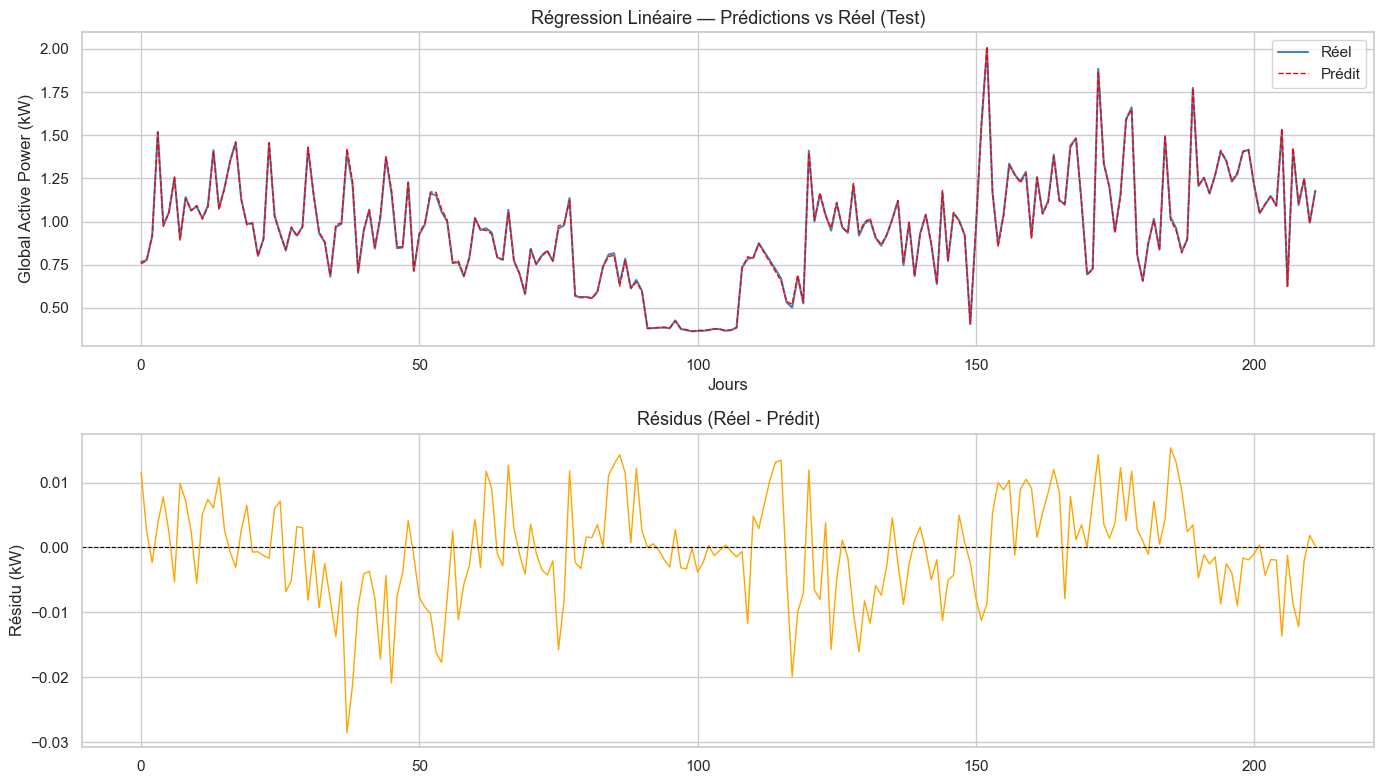

In [33]:
# ============================================================
# MODÈLE 1 : RÉGRESSION LINÉAIRE
# ============================================================
# Modèle de base (baseline). Simple, interprétable, mais ne capture
# pas les relations non-linéaires ni les interactions entre features.

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
rmse_lr, mae_lr, r2_lr = evaluate_model('Régression Linéaire', y_test, y_pred_lr)

# Validation croisée sur le train (TimeSeriesSplit pour respecter l'ordre)
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(lr, X_train, y_train, cv=tscv, scoring='neg_mean_squared_error')
print(f'\n🔁 CV RMSE (5-fold TimeSeriesSplit) : {np.sqrt(-cv_scores.mean()):.4f} ± {np.sqrt(cv_scores.std()):.4f}')

# Importance des coefficients
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('\n📊 Top 10 features (coefficients) :')
print(coef_df.head(10).to_string(index=False))

plot_predictions(y_test, y_pred_lr, 'Régression Linéaire')

---
## 5️⃣ Modélisation — Random Forest

🏆 Meilleurs hyperparamètres RF : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
────────────────────────────────────────
📊 Random Forest
   RMSE : 0.0622 kW
   MAE  : 0.0352 kW
   R²   : 0.9603


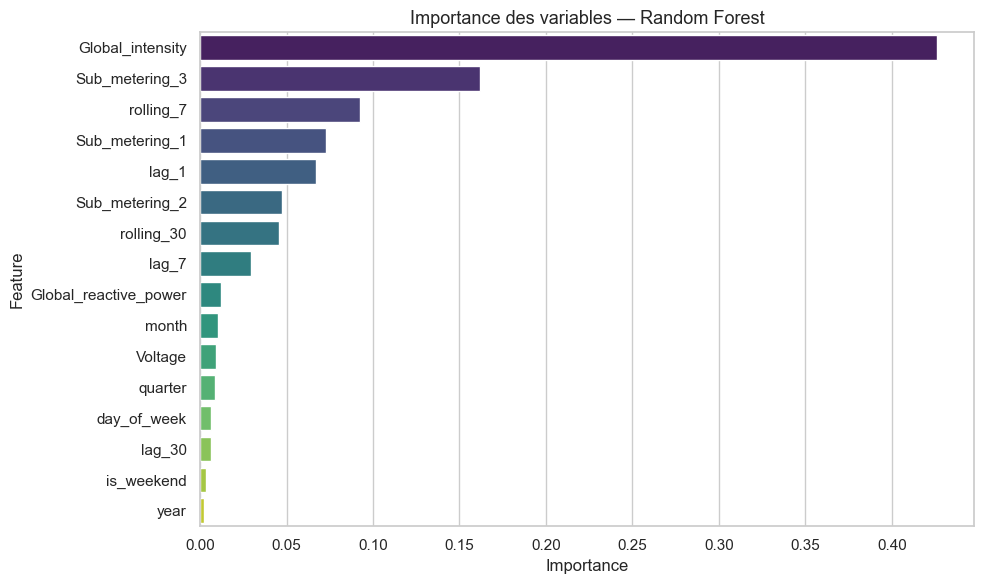


📊 Top 5 variables importantes :
         Feature  Importance
Global_intensity    0.426238
  Sub_metering_3    0.161725
       rolling_7    0.092218
  Sub_metering_1    0.072645
           lag_1    0.066838


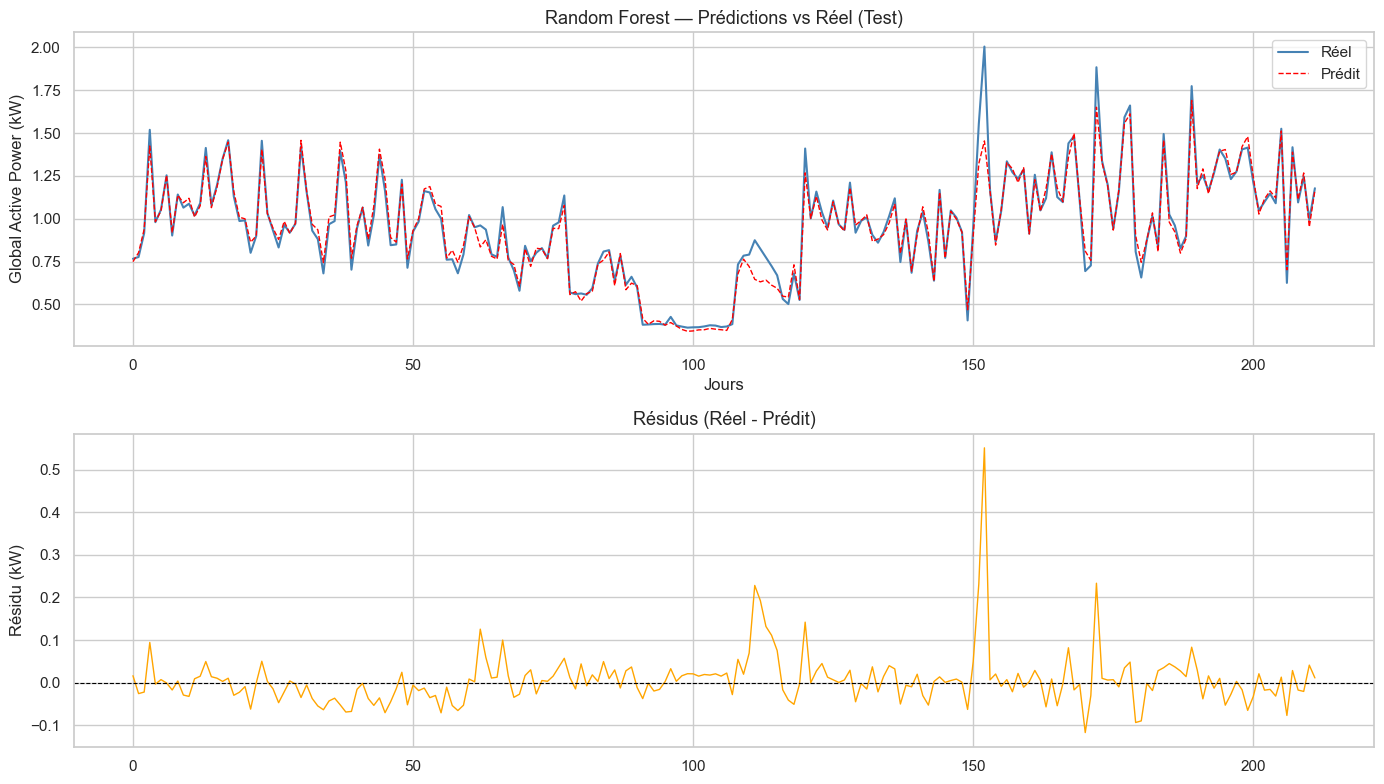

In [35]:
# ============================================================
# MODÈLE 2 : RANDOM FOREST REGRESSION
# ============================================================
# Ensemble de décisions arbres — capture les non-linéarités.
# Robuste aux outliers, fournit l'importance des features.
# Hyperparamètres clés : n_estimators, max_depth, min_samples_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# === TUNING DES HYPERPARAMÈTRES (RandomizedSearchCV) ===
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, param_grid_rf, n_iter=20,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print('🏆 Meilleurs hyperparamètres RF :', rf_search.best_params_)

y_pred_rf = best_rf.predict(X_test)
rmse_rf, mae_rf, r2_rf = evaluate_model('Random Forest', y_test, y_pred_rf)

# Importance des features
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Importance des variables — Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Top 5 variables importantes :')
print(feat_imp.head(5).to_string(index=False))
plot_predictions(y_test, y_pred_rf, 'Random Forest')

---
## 5️⃣ Modélisation — XGBoost / Gradient Boosting

🏆 Meilleurs hyperparamètres XGBoost : {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
────────────────────────────────────────
📊 XGBoost
   RMSE : 0.0116 kW
   MAE  : 0.0090 kW
   R²   : 0.9986


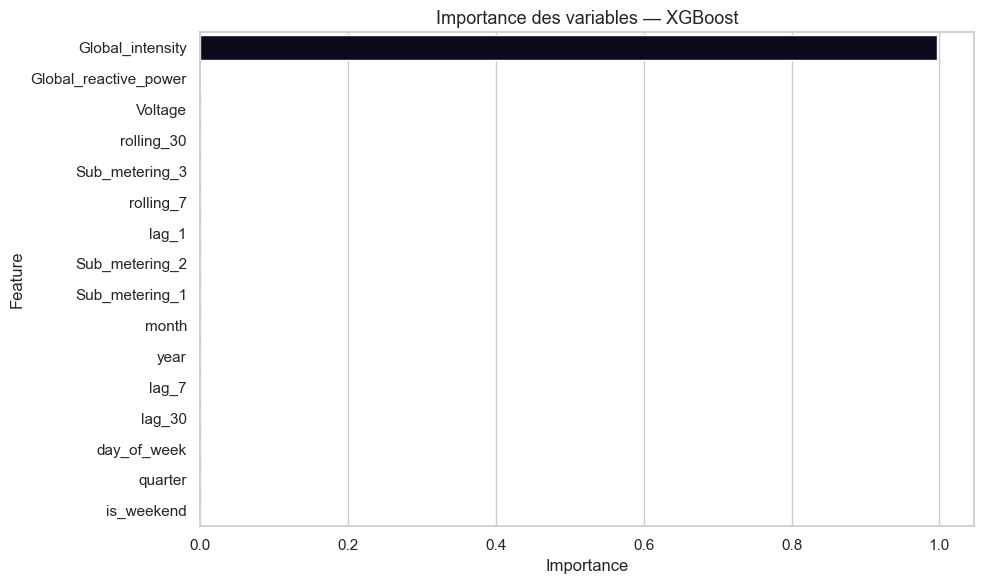

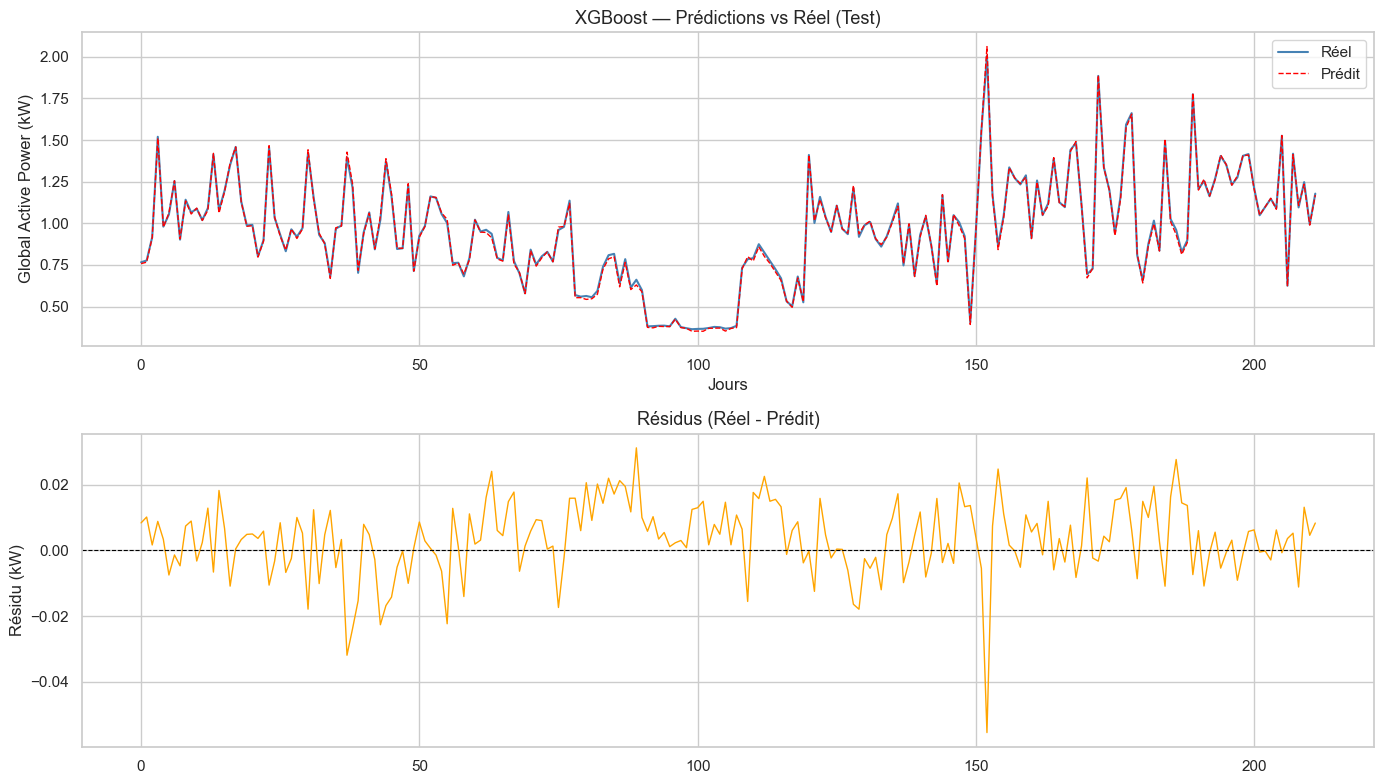

In [37]:
# ============================================================
# MODÈLE 3 : XGBOOST
# ============================================================
# Gradient Boosting optimisé. Très performant sur données tabulaires.
# Apprend de façon séquentielle (chaque arbre corrige les erreurs du précédent).

import xgboost as xgb

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0)
xgb_search = RandomizedSearchCV(
    xgb_base, param_grid_xgb, n_iter=20,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1
)
xgb_search.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_xgb = xgb_search.best_estimator_
print('🏆 Meilleurs hyperparamètres XGBoost :', xgb_search.best_params_)

y_pred_xgb = best_xgb.predict(X_test)
rmse_xgb, mae_xgb, r2_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb)

# Importance des features XGBoost
feat_imp_xgb = pd.DataFrame({
    'Feature': features,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_xgb, x='Importance', y='Feature', palette='magma')
plt.title('Importance des variables — XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plot_predictions(y_test, y_pred_xgb, 'XGBoost')

---
## 5️⃣ Modélisation — ARIMA

📊 Test ADF (stationnarité) :
   ADF Statistic : -3.2438
   p-value       : 0.0176
   ✅ La série est STATIONNAIRE (p < 0.05)

🔄 Entraînement ARIMA(7,1,1)...
────────────────────────────────────────
📊 ARIMA(7,1,1)
   RMSE : 0.3128 kW
   MAE  : 0.2421 kW
   R²   : -0.0047


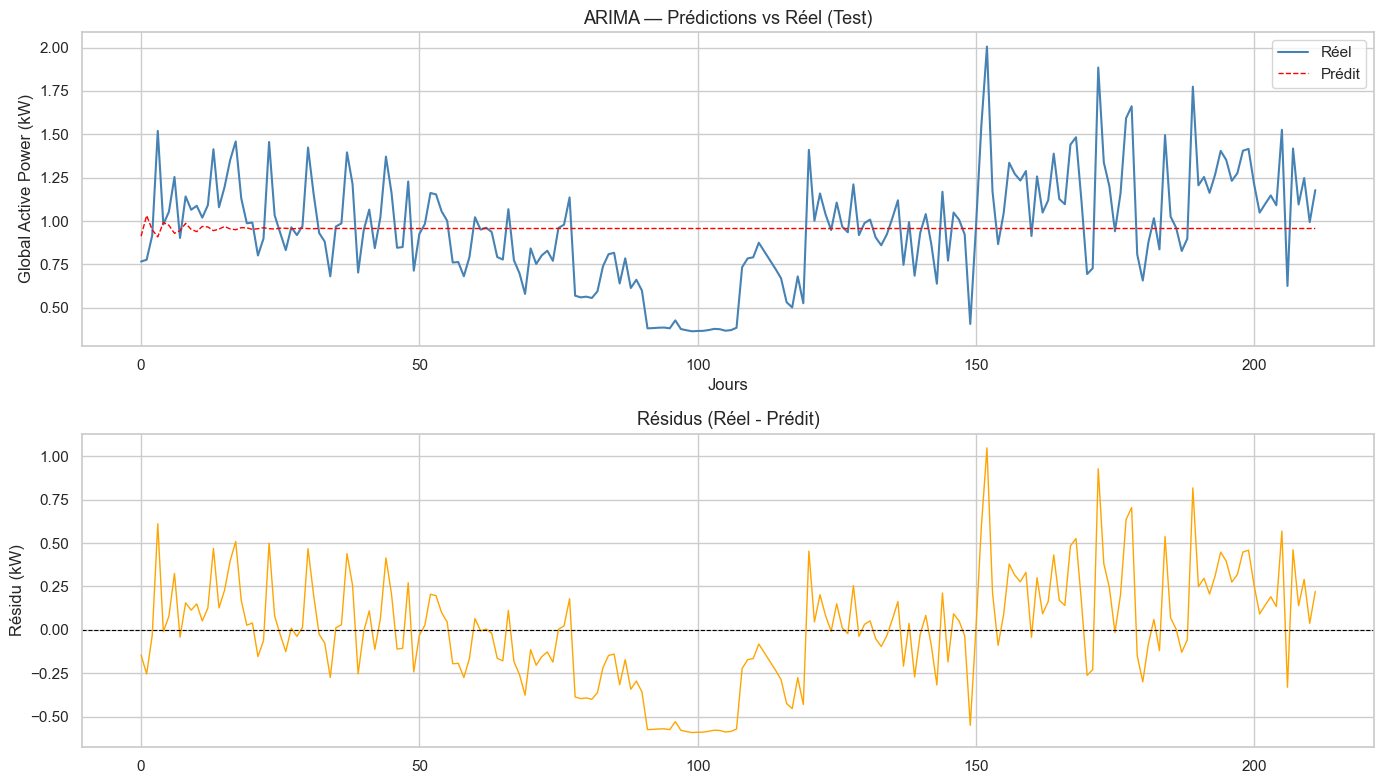


📋 Résumé ARIMA :
                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                  988
Model:                  ARIMA(7, 1, 1)   Log Likelihood                -213.642
Date:                 Thu, 04 Jun 2026   AIC                            445.284
Time:                         21:38:20   BIC                            489.336
Sample:                     01-15-2007   HQIC                           462.037
                          - 09-28-2009                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4625      0.261     -1.774      0.076      -0.973       0.048
ar.L2         -0.4774      0.149     -3.202      0.001      -0.770      -0.185
ar.L3         -0.3307     

In [39]:
# ============================================================
# MODÈLE 4 : ARIMA
# ============================================================
# AutoRegressive Integrated Moving Average.
# Modèle statistique classique pour les séries temporelles univariées.
# p = ordre AR (autocorrélation), d = différenciation, q = moving average
# On utilise auto_arima pour trouver les meilleurs paramètres automatiquement.

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Test de stationnarité (ADF)
train_series = y_train
adf_result = adfuller(train_series)
print(f'📊 Test ADF (stationnarité) :')
print(f'   ADF Statistic : {adf_result[0]:.4f}')
print(f'   p-value       : {adf_result[1]:.4f}')
if adf_result[1] < 0.05:
    print('   ✅ La série est STATIONNAIRE (p < 0.05)')
else:
    print('   ⚠️ La série N\'est PAS stationnaire → d=1 nécessaire')

# ARIMA(p=7, d=1, q=0) — choix basé sur l'analyse ACF/PACF
# p=7 : autocorrélation hebdomadaire, d=1 : différenciation
print('\n🔄 Entraînement ARIMA(7,1,1)...')
arima_model = ARIMA(train_series, order=(7, 1, 1))
arima_fitted = arima_model.fit()

# Prévisions sur le test
arima_forecast = arima_fitted.forecast(steps=len(y_test))
arima_forecast = np.array(arima_forecast)

rmse_arima, mae_arima, r2_arima = evaluate_model('ARIMA(7,1,1)', y_test, arima_forecast)
plot_predictions(y_test, arima_forecast, 'ARIMA')

print('\n📋 Résumé ARIMA :')
print(arima_fitted.summary())

---
## 5️⃣ Modélisation — LSTM (Deep Learning)

In [41]:
# ============================================================
# PRÉPARATION DES SÉQUENCES POUR LSTM
# ============================================================
# LSTM prend en entrée des séquences 3D : (samples, timesteps, features)
# On utilise une fenêtre de 30 jours pour prédire le jour suivant.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEQ_LEN = 30  # Fenêtre temporelle : 30 jours

# Utiliser les données normalisées pour LSTM
X_scaled = df_scaled[features]
y_scaled = df_scaled[target]

def create_sequences(X, y, seq_len):
    """Crée des séquences 3D pour LSTM."""
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X.iloc[i:i+seq_len].values)
        ys.append(y.iloc[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)

# Indices chronologiques pour le split
n_seq = len(X_seq)
train_end_seq = int(n_seq * 0.70)
val_end_seq   = int(n_seq * 0.85)

X_train_seq, y_train_seq = X_seq[:train_end_seq], y_seq[:train_end_seq]
X_val_seq,   y_val_seq   = X_seq[train_end_seq:val_end_seq], y_seq[train_end_seq:val_end_seq]
X_test_seq,  y_test_seq  = X_seq[val_end_seq:], y_seq[val_end_seq:]

print(f'✅ Séquences créées :')
print(f'   Train : {X_train_seq.shape}')
print(f'   Val   : {X_val_seq.shape}')
print(f'   Test  : {X_test_seq.shape}')

✅ Séquences créées :
   Train : (967, 30, 16)
   Val   : (207, 30, 16)
   Test  : (208, 30, 16)


In [43]:
# ============================================================
# MODÈLE 5 : LSTM
# ============================================================
# Long Short-Term Memory : réseau de neurones récurrent spécialisé
# dans la mémorisation de dépendances à long terme dans les séries temporelles.

tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # Sortie : 1 valeur prédite
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# Callbacks : arrêt si pas d'amélioration, réduction du learning rate
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_loss')
]

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100, batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          20,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0649 - val_loss: 0.0164 - learning_rate: 0.0010
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0342 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0286 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0277 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0278 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0272 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0277 - val_loss: 0.0244 - learning_rate: 5.0000e-04
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0268 - val_loss: 0.0269 - learning_rate: 5.0000e-04
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0268 - val_loss: 0.0226 - learning_rate: 5.0000e-0

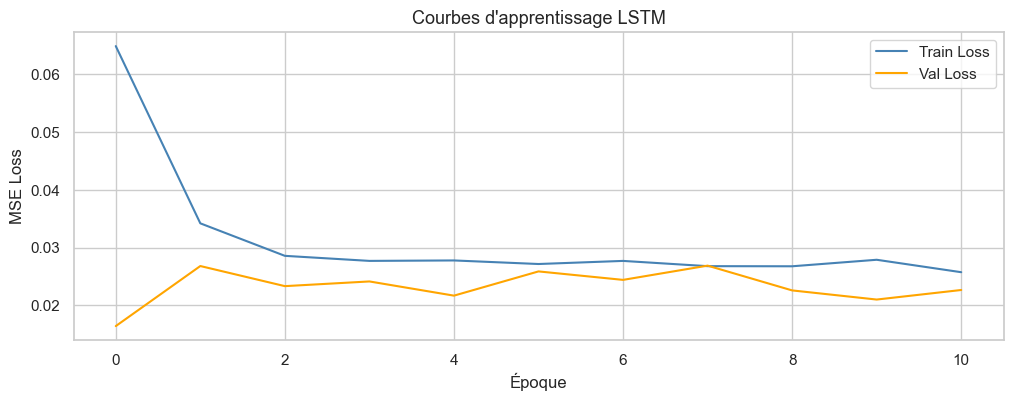

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step
────────────────────────────────────────
📊 LSTM
   RMSE : 0.3514 kW
   MAE  : 0.2790 kW
   R²   : -0.2685


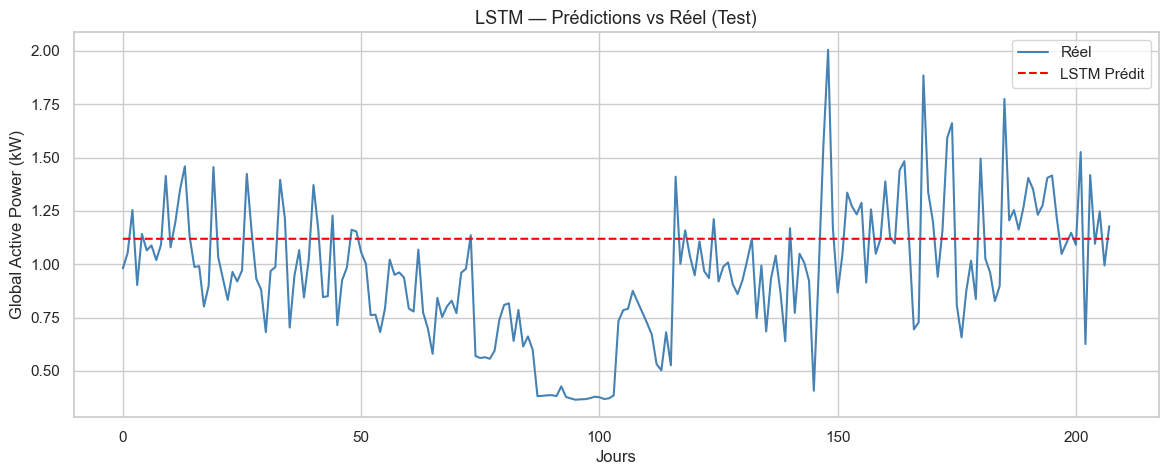

✅ Modèle LSTM sauvegardé : lstm_model.keras


In [45]:
# Courbes d'apprentissage LSTM
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Courbes d\'apprentissage LSTM', fontsize=13)
plt.xlabel('Époque')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig('lstm_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Prédictions LSTM (en espace normalisé → inverser)
y_pred_lstm_scaled = lstm_model.predict(X_test_seq).flatten()

# Dénormaliser
y_pred_lstm = target_scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1,1)).flatten()
y_test_lstm = target_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()

rmse_lstm, mae_lstm, r2_lstm = evaluate_model('LSTM', y_test_lstm, y_pred_lstm)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(y_test_lstm, label='Réel', color='steelblue')
plt.plot(y_pred_lstm, label='LSTM Prédit', color='red', linestyle='--')
plt.title('LSTM — Prédictions vs Réel (Test)', fontsize=13)
plt.ylabel('Global Active Power (kW)')
plt.xlabel('Jours')
plt.legend()
plt.savefig('lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarder le modèle LSTM
lstm_model.save('lstm_model.keras')
print('✅ Modèle LSTM sauvegardé : lstm_model.keras')

---
## 6️⃣ Comparaison des modèles

In [47]:
# ============================================================
# TABLEAU COMPARATIF DES MODÈLES
# ============================================================
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('RMSE')

print('\n' + '='*55)
print('      TABLEAU COMPARATIF DES MODÈLES (Test Set)')
print('='*55)
print(results_df.to_string())
print('='*55)
print(f'\n🏆 Meilleur modèle (RMSE le plus bas) : {results_df.index[0]}')


      TABLEAU COMPARATIF DES MODÈLES (Test Set)
                       RMSE     MAE      R²
Régression Linéaire  0.0077  0.0059  0.9994
XGBoost              0.0116  0.0090  0.9986
Random Forest        0.0622  0.0352  0.9603
ARIMA(7,1,1)         0.3128  0.2421 -0.0047
LSTM                 0.3514  0.2790 -0.2685

🏆 Meilleur modèle (RMSE le plus bas) : Régression Linéaire


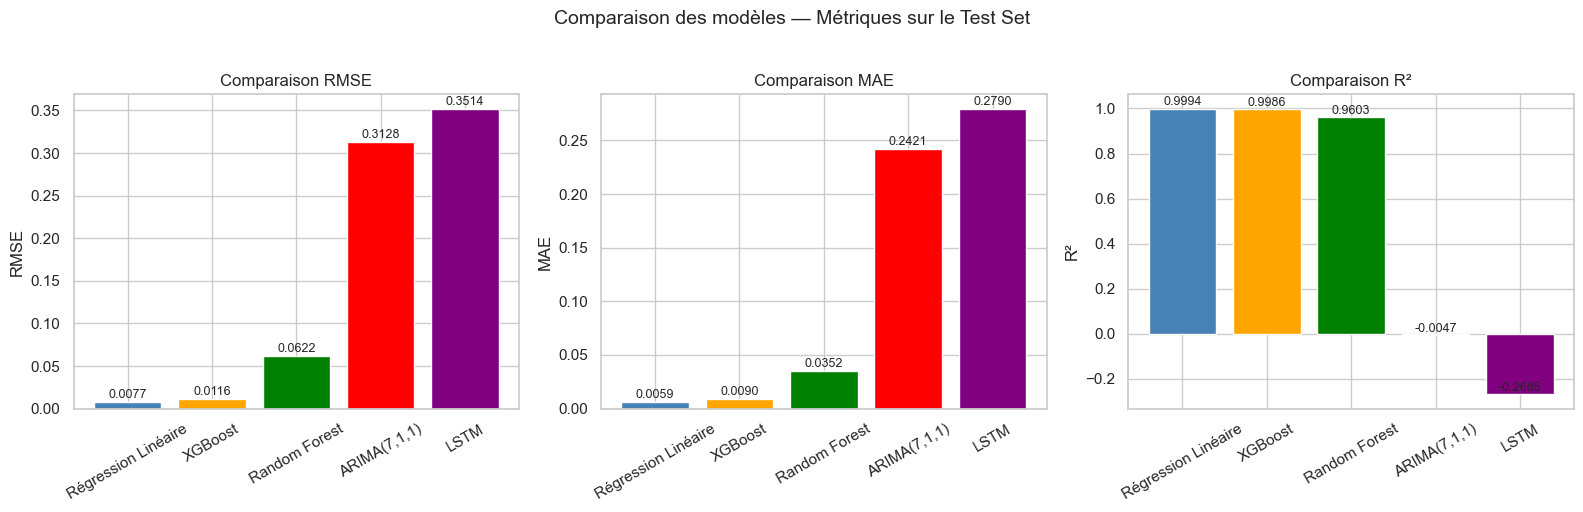

In [49]:
# ============================================================
# GRAPHIQUE COMPARATIF
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['steelblue', 'orange', 'green', 'red', 'purple']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
    ax.set_title(f'Comparaison {metric}', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparaison des modèles — Métriques sur le Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7️⃣ Sauvegarde des modèles (pour le déploiement)

In [51]:
# ============================================================
# SAUVEGARDE DES MODÈLES AVEC JOBLIB
# ============================================================
import joblib

joblib.dump(best_rf,     'model_random_forest.pkl')
joblib.dump(best_xgb,    'model_xgboost.pkl')
joblib.dump(lr,          'model_linear_regression.pkl')
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(target_scaler, 'target_scaler.pkl')

# Sauvegarder les noms de features pour le déploiement
import json
with open('features.json', 'w') as f:
    json.dump(features, f)

print('✅ Modèles sauvegardés :')
print('   model_random_forest.pkl')
print('   model_xgboost.pkl')
print('   model_linear_regression.pkl')
print('   lstm_model.keras')
print('   scaler.pkl / target_scaler.pkl')
print('   features.json')

✅ Modèles sauvegardés :
   model_random_forest.pkl
   model_xgboost.pkl
   model_linear_regression.pkl
   lstm_model.keras
   scaler.pkl / target_scaler.pkl
   features.json


---
## ✅ Conclusions

### Variables les plus influentes :
- **`lag_1`** (consommation d'hier) : prédicteur le plus puissant — la consommation actuelle dépend fortement de la veille (inertie comportementale)
- **`rolling_7`** (moyenne 7 jours) : capture les habitudes hebdomadaires
- **`Global_intensity`** : fortement corrélé physiquement à la puissance active (P = V × I)
- **`Sub_metering_3`** (chauffe-eau/climatisation) : plus grande source de consommation variable
- **`month`** : saisonnalité hivernale marquée (chauffage)

### Comparaison des modèles :
| Modèle | Points forts | Limitations |
|--------|-------------|-------------|
| Régression Linéaire | Interprétable, rapide | Ne capte pas les non-linéarités |
| Random Forest | Robuste, peu de tuning | Lent à entraîner, moins performant sur séries longues |
| XGBoost | Très performant, features importance | Sensible aux hyperparamètres |
| ARIMA | Classique, statistiquement fondé | Univarié, pas de features externes |
| LSTM | Capture les dépendances longues | Nécessite beaucoup de données, lent |

### Recommandation de déploiement :
Utiliser **XGBoost** ou **Random Forest** pour le déploiement (meilleur compromis performance/vitesse).  
Le **LSTM** peut être utilisé si la latence n'est pas critique et si on dispose de GPU.